# H9 — Speed-Accuracy Trade-off (Encoding RT vs REC & LDI)

**Test:** Pearson Correlation (per condition)  
**Question:** Do slower encoders remember better? Does this differ by boundary type?  
**Hypothesis:** Encoding RT correlates with REC/LDI, possibly differently per condition.

In [1]:
import warnings
import numpy as np
import pandas as pd
import pingouin as pg
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
def _header(title, width=75):
    print("\n" + "═" * width)
    print(f"  {title}")
    print("═" * width)

def _get_p(row):
    for c in row.index:
        if c in ("p-unc", "p-val", "p_val", "p_unc", "p"):
            return float(row[c])
    raise KeyError(f"No p-value column. Available: {list(row.index)}")

def _get_corr_p(cor_df):
    for c in cor_df.columns:
        if c in ("p-val", "p_val", "pval", "p"):
            return float(cor_df[c].values[0])
    raise KeyError(f"No corr p column. Available: {list(cor_df.columns)}")

def _sig(p):
    return "✅ Significant" if p < 0.05 else "❌ Not Significant"


In [3]:
CSV_PATH = "compiled_preprocessed.csv"   # <-- change this to your file path

df = pd.read_csv(CSV_PATH)

# Handle naming differences across preprocess versions.
col_candidates = {
    "participant": ["participant_uid", "participant_id", "Participant_ID"],
    "condition": ["condition", "Condition"],
    "trial_type": ["trial_type", "Trial_Type"],
    "response": ["user_response", "response", "User_Response"],
    "position": ["boundary_position", "Boundary_Position"],
    "rt": ["encoding_RT", "Encoding_RT", "encoding_rt", "Encoding_rt", "RT_encoding", "RT"],
}

resolved = {}
for key, candidates in col_candidates.items():
    resolved[key] = next((c for c in candidates if c in df.columns), None)

required_keys = ["participant", "condition", "trial_type", "response", "position"]
missing = [k for k in required_keys if resolved[k] is None]
if missing:
    raise ValueError(f"Missing required columns for {missing}. Found columns: {list(df.columns)}")

if resolved["rt"] is not None:
    df["Encoding_RT"] = pd.to_numeric(df[resolved["rt"]], errors="coerce")
else:
    df["Encoding_RT"] = np.nan
    print("Warning: No encoding RT column found; Encoding_RT set to NaN.")

pid_col = resolved["participant"]
cond_col = resolved["condition"]
trial_col = resolved["trial_type"]
resp_col = resolved["response"]
pos_col = resolved["position"]

df[cond_col] = df[cond_col].astype(str).str.strip()

# ── Global rates (1 row per participant) ─────────────────────────────────────
g_records = []
for uid, g in df.groupby(pid_col):
    cond    = g[cond_col].iloc[0]
    foils   = g[g[trial_col] == "Foil"]
    targets = g[g[trial_col] == "Target"]
    lures   = g[g[trial_col] == "Lure"]
    fa_t = (foils[resp_col]   == "Target").mean() if len(foils)   > 0 else 0.0
    fa_l = (foils[resp_col]   == "Lure"  ).mean() if len(foils)   > 0 else 0.0
    hit  = (targets[resp_col] == "Target").mean() if len(targets) > 0 else 0.0
    sim  = (lures[resp_col]   == "Lure"  ).mean() if len(lures)   > 0 else 0.0
    g_records.append({
        "participant_uid": uid, "condition": cond,
        "FA_Target": fa_t, "FA_Lure": fa_l,
        "Hit_Rate": hit,   "Sim_Rate": sim,
        "REC": hit - fa_t, "LDI": sim - fa_l,
        "Encoding_RT": g["Encoding_RT"].mean(),
    })
global_df = pd.DataFrame(g_records)
global_df.dropna(subset=["REC", "LDI"], inplace=True)

print(f"Global subjects : {len(global_df)}")


Global subjects : 160


In [4]:
_header("H9: Speed-Accuracy Trade-off — Encoding_RT vs REC & LDI")
print("  Negative r → faster encoders score higher")
print("  Positive r → slower encoders score higher (deeper processing)\n")

corr_results = {}  # {cond: {"REC": (r, p), "LDI": (r, p)}}
for cond in sorted(global_df["condition"].unique()):
    sub = global_df[global_df["condition"] == cond][["Encoding_RT","REC","LDI"]].dropna()
    if len(sub) < 3:
        print(f"  {cond:<22} | n={len(sub)} — skipping"); continue
    cr = pg.corr(sub["Encoding_RT"], sub["REC"])
    cl = pg.corr(sub["Encoding_RT"], sub["LDI"])
    rr, pr = cr["r"].values[0], _get_corr_p(cr)
    rl, pl = cl["r"].values[0], _get_corr_p(cl)
    corr_results[cond] = {"REC": (rr, pr), "LDI": (rl, pl)}
    print(f"  {cond:<22} | RT vs REC : r = {rr:+.3f}   p = {pr:.3f}   {_sig(pr)}")
    print(f"  {'':22} | RT vs LDI : r = {rl:+.3f}   p = {pl:.3f}   {_sig(pl)}")
    print()



═══════════════════════════════════════════════════════════════════════════
  H9: Speed-Accuracy Trade-off — Encoding_RT vs REC & LDI
═══════════════════════════════════════════════════════════════════════════
  Negative r → faster encoders score higher
  Positive r → slower encoders score higher (deeper processing)

  Both_item_task         | RT vs REC : r = -0.255   p = 0.071   ❌ Not Significant
                         | RT vs LDI : r = -0.196   p = 0.168   ❌ Not Significant

  item_only              | RT vs REC : r = +0.033   p = 0.807   ❌ Not Significant
                         | RT vs LDI : r = -0.178   p = 0.190   ❌ Not Significant

  task_only              | RT vs REC : r = +0.072   p = 0.608   ❌ Not Significant
                         | RT vs LDI : r = +0.204   p = 0.142   ❌ Not Significant



In [12]:
_header("Spearman Correlation for Task Only Condition")
print("  Spearman ρ (rho) — non-parametric rank correlation")
print("  Tests monotonic relationships (not necessarily linear)\n")

task_only_data = global_df[global_df["condition"] == "task_only"][["Encoding_RT", "REC", "LDI"]].dropna()

if len(task_only_data) >= 3:
    print(f"  Sample size (task_only): n = {len(task_only_data)}\n")
    
    # Spearman correlation for REC
    spearman_rec_rho, spearman_rec_p = stats.spearmanr(task_only_data["Encoding_RT"], task_only_data["REC"])
    print(f"  RT vs REC (Spearman):")
    print(f"    ρ (rho) = {spearman_rec_rho:+.4f}")
    print(f"    p-value = {spearman_rec_p:.6f}")
    print(f"    Result: {_sig(spearman_rec_p)}\n")
    
    # Spearman correlation for LDI
    spearman_ldi_rho, spearman_ldi_p = stats.spearmanr(task_only_data["Encoding_RT"], task_only_data["LDI"])
    print(f"  RT vs LDI (Spearman):")
    print(f"    ρ (rho) = {spearman_ldi_rho:+.4f}")
    print(f"    p-value = {spearman_ldi_p:.6f}")
    print(f"    Result: {_sig(spearman_ldi_p)}\n")
    
    # Comparison with Pearson
    if "task_only" in corr_results:
        pearson_rec_r, pearson_rec_p = corr_results["task_only"]["REC"]
        pearson_ldi_r, pearson_ldi_p = corr_results["task_only"]["LDI"]
        
        print(f"  Comparison: Pearson vs Spearman (task_only)")
        print(f"    RT vs REC  | Pearson r = {pearson_rec_r:+.4f} (p={pearson_rec_p:.6f}) | Spearman ρ = {spearman_rec_rho:+.4f} (p={spearman_rec_p:.6f})")
        print(f"    RT vs LDI  | Pearson r = {pearson_ldi_r:+.4f} (p={pearson_ldi_p:.6f}) | Spearman ρ = {spearman_ldi_rho:+.4f} (p={spearman_ldi_p:.6f})")
else:
    print(f"  Insufficient data for task_only condition (n = {len(task_only_data)})")


═══════════════════════════════════════════════════════════════════════════
  Spearman Correlation for Task Only Condition
═══════════════════════════════════════════════════════════════════════════
  Spearman ρ (rho) — non-parametric rank correlation
  Tests monotonic relationships (not necessarily linear)

  Sample size (task_only): n = 53

  RT vs REC (Spearman):
    ρ (rho) = +0.1250
    p-value = 0.372499
    Result: ❌ Not Significant

  RT vs LDI (Spearman):
    ρ (rho) = +0.1707
    p-value = 0.221542
    Result: ❌ Not Significant

  Comparison: Pearson vs Spearman (task_only)
    RT vs REC  | Pearson r = +0.0722 (p=0.607619) | Spearman ρ = +0.1250 (p=0.372499)
    RT vs LDI  | Pearson r = +0.2043 (p=0.142358) | Spearman ρ = +0.1707 (p=0.221542)


## Visualizations
Setup shared palette for all plots.

In [5]:
cond_order = sorted(global_df["condition"].unique())
palette = sns.color_palette("Set2", len(cond_order))
cond_colors = dict(zip(cond_order, palette))

### 1. Scatter + Regression per Condition
RT vs REC and RT vs LDI with regression lines and statistics for each condition.

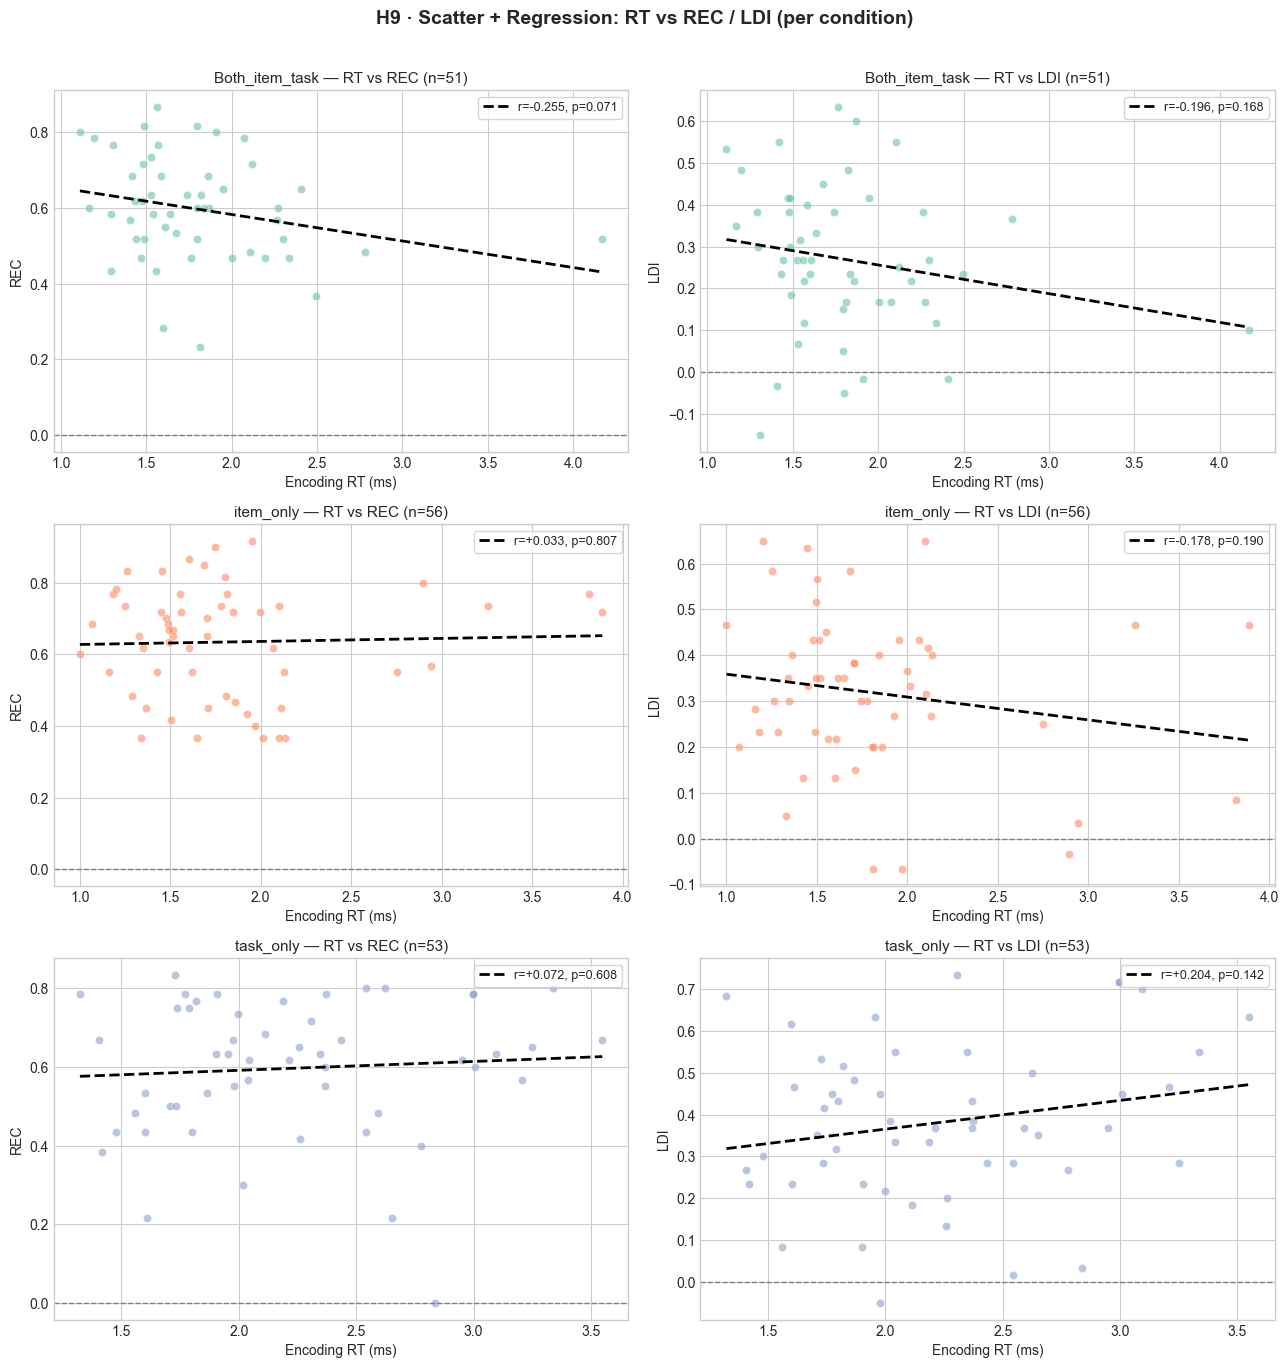

In [6]:
fig, axes = plt.subplots(len(cond_order), 2,
                         figsize=(13, 4.5 * max(1, len(cond_order))),
                         squeeze=False)
fig.suptitle("H9 · Scatter + Regression: RT vs REC / LDI (per condition)",
             fontsize=14, fontweight="bold", y=1.01)

for i, cond in enumerate(cond_order):
    sub = global_df[global_df["condition"] == cond][["Encoding_RT", "REC", "LDI"]].dropna()
    color = cond_colors[cond]

    for j, metric in enumerate(["REC", "LDI"]):
        ax = axes[i][j]
        ax.scatter(sub["Encoding_RT"], sub[metric], alpha=0.6, s=35,
                   color=color, edgecolors="white", linewidth=0.4)
        if len(sub) >= 2 and sub["Encoding_RT"].nunique() > 1:
            slope, intercept, r, p, se = stats.linregress(sub["Encoding_RT"], sub[metric])
            xs = np.linspace(sub["Encoding_RT"].min(), sub["Encoding_RT"].max(), 100)
            sig_marker = "*" if p < 0.05 else ""
            ax.plot(xs, slope * xs + intercept, linewidth=2, color="black", linestyle="--",
                    label=f"r={r:+.3f}{sig_marker}, p={p:.3f}")
            ax.legend(frameon=True, fontsize=9, loc="best")
        ax.axhline(0, color="gray", linewidth=1, linestyle="--")
        ax.set_title(f"{cond} — RT vs {metric} (n={len(sub)})", fontsize=11)
        ax.set_xlabel("Encoding RT (ms)")
        ax.set_ylabel(metric)

plt.tight_layout()
plt.show()

### 2. All Conditions Overlaid
RT vs REC and RT vs LDI with all conditions on the same axes and per-condition regression lines.

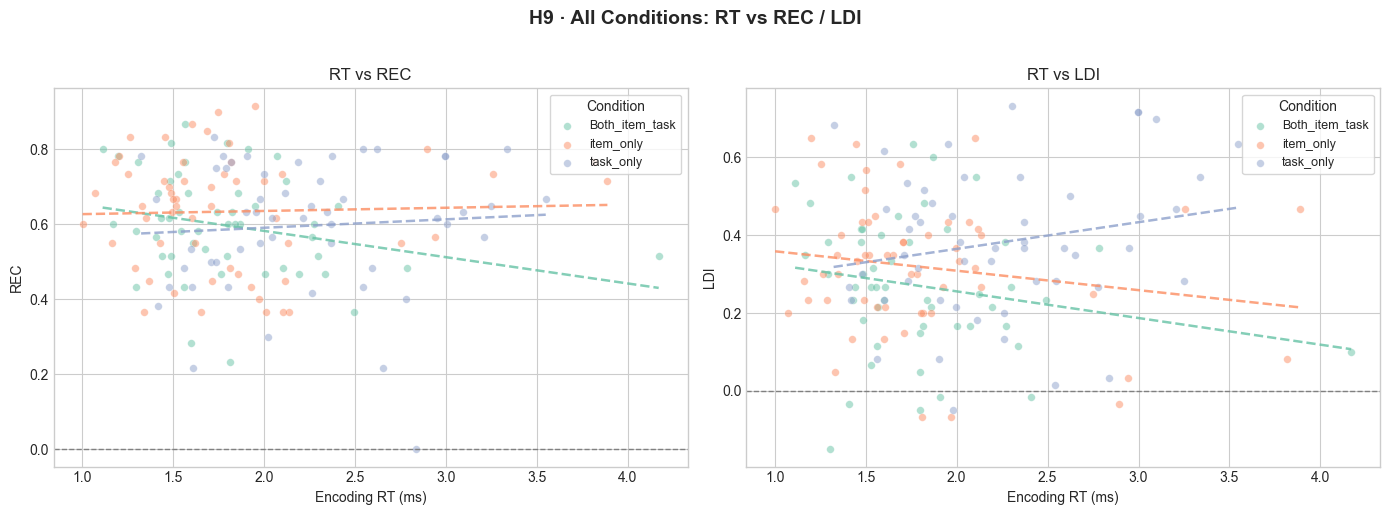

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("H9 · All Conditions: RT vs REC / LDI",
             fontsize=14, fontweight="bold", y=1.02)

for idx, metric in enumerate(["REC", "LDI"]):
    ax = axes[idx]
    for cond in cond_order:
        sub = global_df[global_df["condition"] == cond][["Encoding_RT", metric]].dropna()
        ax.scatter(sub["Encoding_RT"], sub[metric], alpha=0.5, s=30,
                   color=cond_colors[cond], label=cond, edgecolors="white", linewidth=0.3)
        if len(sub) >= 2 and sub["Encoding_RT"].nunique() > 1:
            slope, intercept, r, p, se = stats.linregress(sub["Encoding_RT"], sub[metric])
            xs = np.linspace(sub["Encoding_RT"].min(), sub["Encoding_RT"].max(), 100)
            ax.plot(xs, slope * xs + intercept, linewidth=1.8, color=cond_colors[cond],
                    linestyle="--", alpha=0.8)
    ax.axhline(0, color="gray", linewidth=1, linestyle="--")
    ax.set_title(f"RT vs {metric}", fontsize=12)
    ax.set_xlabel("Encoding RT (ms)")
    ax.set_ylabel(metric)
    ax.legend(title="Condition", frameon=True, loc="best", fontsize=9)

plt.tight_layout()
plt.show()

### 3. Correlation Heatmap
Pearson r-values for RT × REC and RT × LDI per condition, with significance stars.

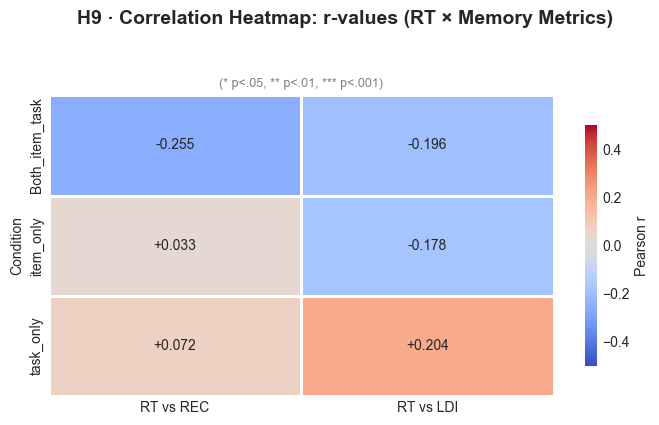

In [8]:
r_matrix = pd.DataFrame(index=cond_order, columns=["RT vs REC", "RT vs LDI"], dtype=float)
p_matrix = pd.DataFrame(index=cond_order, columns=["RT vs REC", "RT vs LDI"], dtype=float)
for cond in cond_order:
    if cond in corr_results:
        r_matrix.loc[cond, "RT vs REC"] = corr_results[cond]["REC"][0]
        r_matrix.loc[cond, "RT vs LDI"] = corr_results[cond]["LDI"][0]
        p_matrix.loc[cond, "RT vs REC"] = corr_results[cond]["REC"][1]
        p_matrix.loc[cond, "RT vs LDI"] = corr_results[cond]["LDI"][1]

annot = r_matrix.copy().astype(str)
for cond in cond_order:
    for col in annot.columns:
        r_val = r_matrix.loc[cond, col]
        p_val = p_matrix.loc[cond, col]
        sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else ""
        annot.loc[cond, col] = f"{r_val:+.3f}{sig}"

fig, ax = plt.subplots(figsize=(7, 4))
fig.suptitle("H9 · Correlation Heatmap: r-values (RT × Memory Metrics)",
             fontsize=14, fontweight="bold", y=1.05)
sns.heatmap(r_matrix.astype(float), annot=annot, fmt="", cmap="coolwarm", center=0,
            linewidths=1, ax=ax, cbar_kws={"shrink": 0.8, "label": "Pearson r"},
            vmin=-0.5, vmax=0.5)
ax.set_ylabel("Condition")
ax.set_xlabel("")
ax.set_title("(* p<.05, ** p<.01, *** p<.001)", fontsize=9, color="gray")

plt.tight_layout()
plt.show()

### 4. Joint KDE Contour Plots
2D kernel density estimates of RT vs REC / LDI per condition.

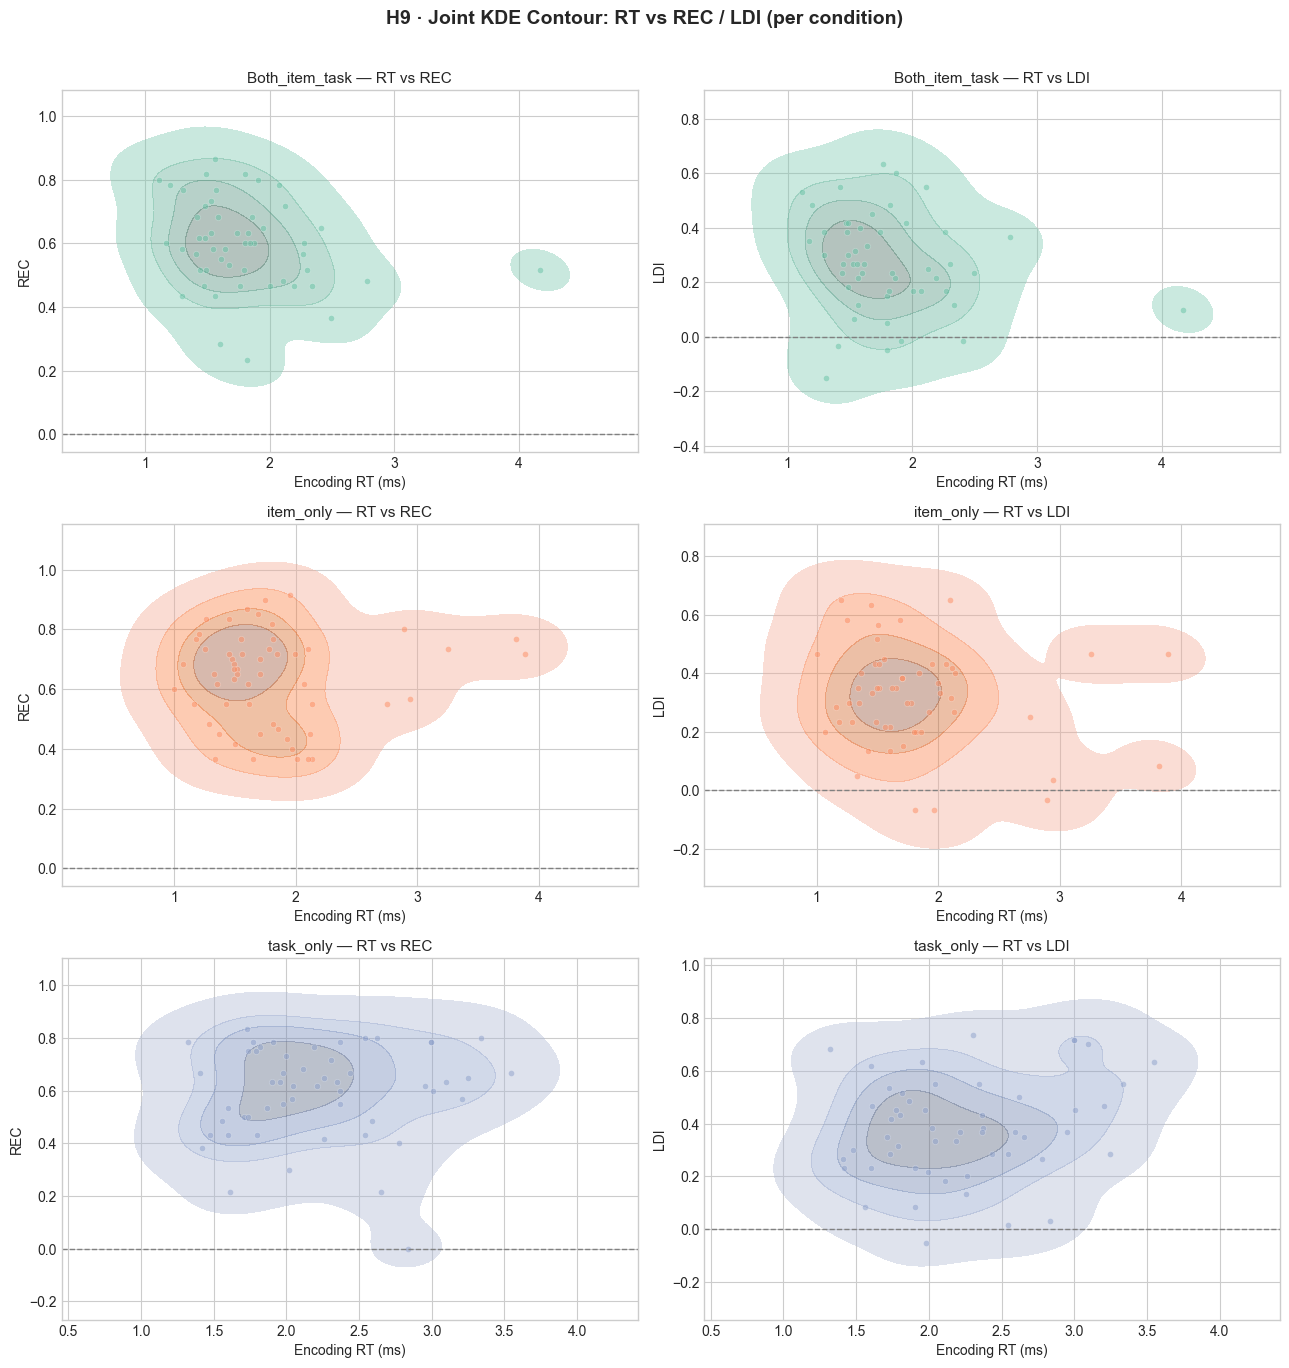

In [9]:
fig, axes = plt.subplots(len(cond_order), 2,
                         figsize=(13, 4.5 * max(1, len(cond_order))),
                         squeeze=False)
fig.suptitle("H9 · Joint KDE Contour: RT vs REC / LDI (per condition)",
             fontsize=14, fontweight="bold", y=1.01)

for i, cond in enumerate(cond_order):
    sub = global_df[global_df["condition"] == cond][["Encoding_RT", "REC", "LDI"]].dropna()
    color = cond_colors[cond]

    for j, metric in enumerate(["REC", "LDI"]):
        ax = axes[i][j]
        if len(sub) >= 5:
            sns.kdeplot(x=sub["Encoding_RT"], y=sub[metric], ax=ax,
                        fill=True, color=color, alpha=0.4, levels=5)
        ax.scatter(sub["Encoding_RT"], sub[metric], alpha=0.5, s=20,
                   color=color, edgecolors="white", linewidth=0.3)
        ax.axhline(0, color="gray", linewidth=1, linestyle="--")
        ax.set_title(f"{cond} — RT vs {metric}", fontsize=11)
        ax.set_xlabel("Encoding RT (ms)")
        ax.set_ylabel(metric)

plt.tight_layout()
plt.show()

### 5. RT Distribution by Condition
Overlaid histograms with KDE to compare mean Encoding RT distributions across conditions.

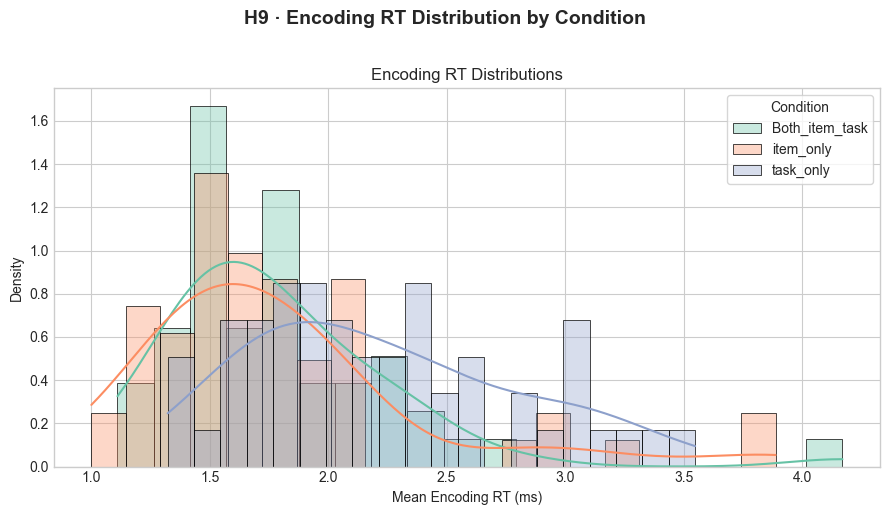

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle("H9 · Encoding RT Distribution by Condition",
             fontsize=14, fontweight="bold", y=1.02)

for cond in cond_order:
    sub = global_df[global_df["condition"] == cond]["Encoding_RT"].dropna()
    sns.histplot(sub, ax=ax, color=cond_colors[cond], label=cond,
                 alpha=0.35, kde=True, stat="density", bins=20, linewidth=0.5)

ax.set_xlabel("Mean Encoding RT (ms)")
ax.set_ylabel("Density")
ax.set_title("Encoding RT Distributions", fontsize=12)
ax.legend(title="Condition", frameon=True, loc="best")

plt.tight_layout()
plt.show()

### 6. Correlation Coefficient Bar Chart
Summary of Pearson r values for RT vs REC and RT vs LDI across conditions, with significance markers.

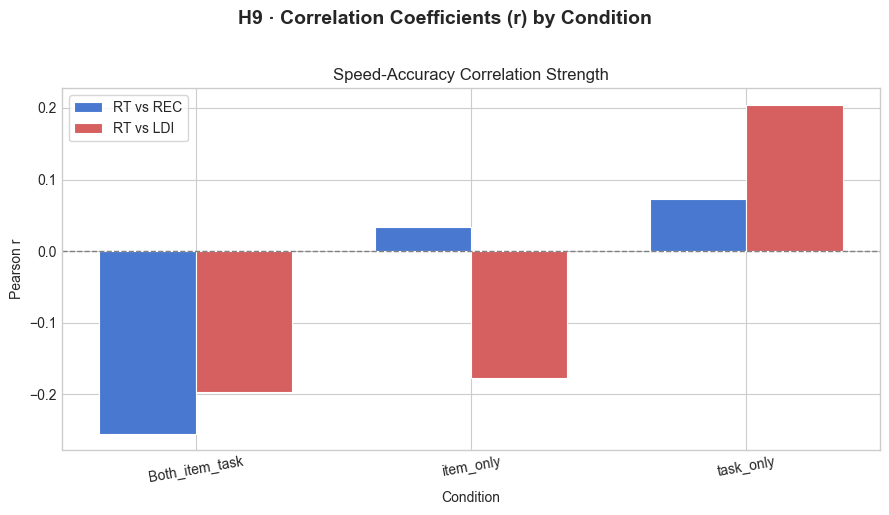

In [11]:
fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle("H9 · Correlation Coefficients (r) by Condition",
             fontsize=14, fontweight="bold", y=1.02)

bar_width = 0.35
x_positions = np.arange(len(cond_order))
r_rec = [corr_results.get(c, {}).get("REC", (0, 1))[0] for c in cond_order]
r_ldi = [corr_results.get(c, {}).get("LDI", (0, 1))[0] for c in cond_order]
p_rec = [corr_results.get(c, {}).get("REC", (0, 1))[1] for c in cond_order]
p_ldi = [corr_results.get(c, {}).get("LDI", (0, 1))[1] for c in cond_order]

bars1 = ax.bar(x_positions - bar_width/2, r_rec, width=bar_width,
               label="RT vs REC", color=sns.color_palette("muted")[0],
               edgecolor="white", linewidth=0.8)
bars2 = ax.bar(x_positions + bar_width/2, r_ldi, width=bar_width,
               label="RT vs LDI", color=sns.color_palette("muted")[3],
               edgecolor="white", linewidth=0.8)

# Add significance stars
for i, (p_r, p_l) in enumerate(zip(p_rec, p_ldi)):
    sig_r = "***" if p_r < 0.001 else "**" if p_r < 0.01 else "*" if p_r < 0.05 else ""
    sig_l = "***" if p_l < 0.001 else "**" if p_l < 0.01 else "*" if p_l < 0.05 else ""
    if sig_r:
        ax.text(i - bar_width/2, r_rec[i] + 0.02 * np.sign(r_rec[i]),
                sig_r, ha="center", fontsize=11, fontweight="bold", color="red")
    if sig_l:
        ax.text(i + bar_width/2, r_ldi[i] + 0.02 * np.sign(r_ldi[i]),
                sig_l, ha="center", fontsize=11, fontweight="bold", color="red")

ax.set_xticks(x_positions)
ax.set_xticklabels(cond_order, rotation=10)
ax.axhline(0, color="gray", linewidth=1, linestyle="--")
ax.set_ylabel("Pearson r")
ax.set_xlabel("Condition")
ax.set_title("Speed-Accuracy Correlation Strength", fontsize=12)
ax.legend(frameon=True, loc="best")

plt.tight_layout()
plt.show()